In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [4]:
print("Total Ratings:", ratings.shape)
print("Unique Users:", ratings['userId'].nunique())
print("Unique Movies:", ratings['movieId'].nunique())

Total Ratings: (100836, 4)
Unique Users: 610
Unique Movies: 9724


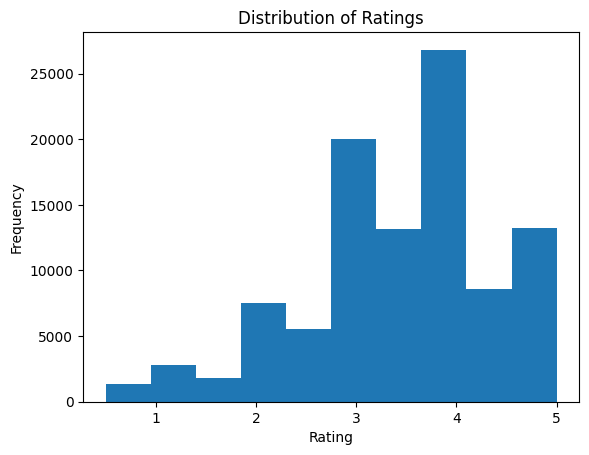

In [5]:
plt.hist(ratings['rating'], bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [6]:
train_data, test_data = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

In [7]:
user_movie_matrix = train_data.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
user_similarity = cosine_similarity(user_movie_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.016314,0.049021,0.165799,0.123392,0.118556,0.112563,0.142135,0.056088,0.012906,...,0.070901,0.152097,0.187324,0.067264,0.151517,0.139042,0.198771,0.232811,0.112174,0.143902
2,0.016314,1.000000,0.000000,0.004627,0.000000,0.013391,0.029067,0.032754,0.000000,0.080739,...,0.170123,0.020395,0.014415,0.000000,0.000000,0.019846,0.016076,0.055610,0.032404,0.075810
3,0.049021,0.000000,1.000000,0.000000,0.005770,0.004833,0.000000,0.005911,0.000000,0.000000,...,0.006401,0.005889,0.015344,0.000000,0.012783,0.008884,0.004642,0.009433,0.000000,0.031309
4,0.165799,0.004627,0.000000,1.000000,0.133565,0.090914,0.094497,0.050417,0.000000,0.021991,...,0.075828,0.090252,0.241155,0.054366,0.081585,0.162277,0.083074,0.107276,0.026720,0.068325
5,0.123392,0.000000,0.005770,0.133565,1.000000,0.238812,0.071386,0.393773,0.000000,0.006245,...,0.050523,0.343953,0.101064,0.159651,0.111464,0.086797,0.073278,0.097040,0.205395,0.053090


In [9]:
def recommend_movies(user_id, top_n=5):
    
    if user_id not in user_movie_matrix.index:
        return "User not found"
    
    # Similarity scores
    similar_users = user_similarity_df[user_id]
    
    # Remove self similarity
    similar_users = similar_users.drop(user_id)
    
    # Remove same user from matrix
    filtered_matrix = user_movie_matrix.drop(index=user_id)
    
    # Weighted ratings
    weighted_ratings = np.dot(similar_users.values, filtered_matrix.values)
    
    recommendation_scores = pd.Series(
        weighted_ratings,
        index=user_movie_matrix.columns
    )
    
    # Remove already rated movies
    already_rated = user_movie_matrix.loc[user_id]
    recommendation_scores = recommendation_scores[already_rated == 0]
    
    return recommendation_scores.sort_values(ascending=False).head(top_n)

In [10]:
recommend_movies(user_id=1, top_n=5)

movieId
318     152.418759
589     116.586712
1198    112.929267
858     101.944324
4993     90.680206
dtype: float64

In [11]:
def recommend_movie_titles(user_id, top_n=5):
    
    recommendations = recommend_movies(user_id, top_n)
    
    movie_ids = recommendations.index
    
    return movies[movies['movieId'].isin(movie_ids)][['movieId', 'title']]

In [12]:
recommend_movie_titles(user_id=1, top_n=5)

,movieId,title
277,318,"Shawshank Redemption, The (1994)"
507,589,Terminator 2: Judgment Day (1991)
659,858,"Godfather, The (1972)"
900,1198,Raiders of the Lost Ark (Indiana Jones and the...
3638,4993,"Lord of the Rings: The Fellowship of the Ring,..."


In [13]:
def predict_rating(user_id, movie_id):
    
    if user_id not in user_movie_matrix.index:
        return np.nan
    
    similar_users = user_similarity_df[user_id]
    movie_ratings = user_movie_matrix[movie_id]
    
    numerator = np.dot(similar_users, movie_ratings)
    denominator = similar_users.sum()
    
    if denominator == 0:
        return 0
    
    return numerator / denominator

In [14]:
y_true = []
y_pred = []

for row in test_data.itertuples():
    if row.movieId in user_movie_matrix.columns:
        pred = predict_rating(row.userId, row.movieId)
        
        if not np.isnan(pred):
            y_true.append(row.rating)
            y_pred.append(pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("RMSE:", rmse)

RMSE: 3.225091435656035
